Juan Cisneros jc222256
Sarah Rincon sr56495
Juan Arellano jma6353

Section 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
m = 335       
c = 545.5 
k = 20000     

# initial conditions
y0 = 0.05     #initial displacement
v0 = 0.0      #initial velocity

#time settings
t0 = 0
tf = 10

def system(t, Y):
# converts the second-order ODE into a system of two first-order ODEs
# y[0] = displacement
# y[1] = velocity
    y = Y[0]
    v = Y[1]
    
    dydt = v
    dvdt = -(c/m)*v - (k/m)*y
    
    return np.array([dydt, dvdt])


def euler_method(h):

#forward euler method for solving the suspension system
    t_values = np.arange(t0, tf + h, h)
    Y = np.zeros((len(t_values), 2))
    
    Y[0] = [y0, v0]
    
    for i in range(len(t_values) - 1):
        Y[i+1] = Y[i] + h * system(t_values[i], Y[i])
    
    return t_values, Y


def rk4_method(h):
#fourth order Runge-Kutta method for solving the suspension system
    t_values = np.arange(t0, tf + h, h)
    Y = np.zeros((len(t_values), 2))
    
    Y[0] = [y0, v0]
    
    for i in range(len(t_values) - 1):
        t = t_values[i]
        
        k1 = system(t, Y[i])
        k2 = system(t + h/2, Y[i] + (h/2)*k1)
        k3 = system(t + h/2, Y[i] + (h/2)*k2)
        k4 = system(t + h, Y[i] + h*k3)
        
        Y[i+1] = Y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    
    return t_values, Y

Section 4

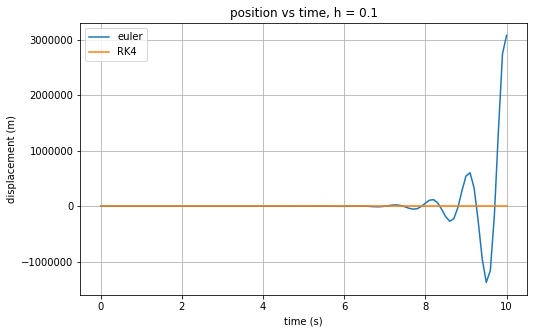

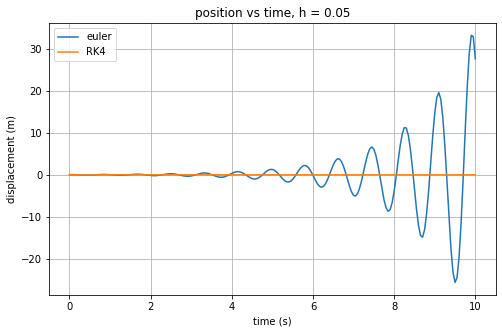

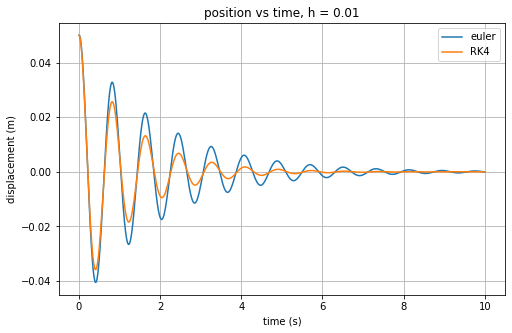

In [9]:
h_values = [0.1, 0.05, 0.01]

for h in h_values:
    t_euler, Y_euler = euler_method(h)
    t_rk4, Y_rk4 = rk4_method(h)
    
    plt.figure(figsize=(8,5))
    plt.plot(t_euler, Y_euler[:,0], label="euler")
    plt.plot(t_rk4, Y_rk4[:,0], label="RK4")
    plt.xlabel("time (s)")
    plt.ylabel("displacement (m)")
    plt.title("position vs time, h = " + str(h))
    plt.legend()
    plt.grid(True)
    plt.show()

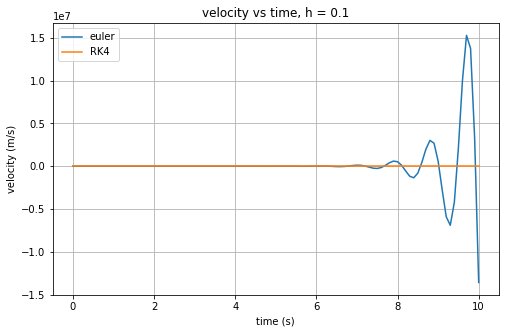

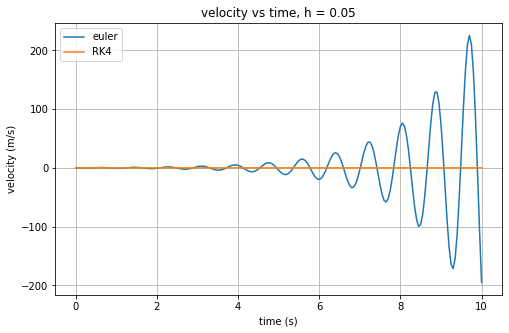

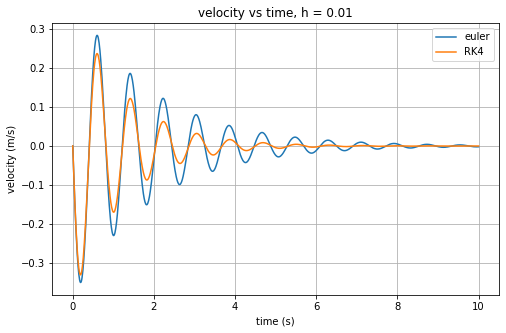

In [10]:
for h in h_values:
    t_euler, Y_euler = euler_method(h)
    t_rk4, Y_rk4 = rk4_method(h)
    
    plt.figure(figsize=(8,5))
    plt.plot(t_euler, Y_euler[:,1], label="euler")
    plt.plot(t_rk4, Y_rk4[:,1], label="RK4")
    plt.xlabel("time (s)")
    plt.ylabel("velocity (m/s)")
    plt.title("velocity vs time, h = " + str(h))
    plt.legend()
    plt.grid(True)
    plt.show()

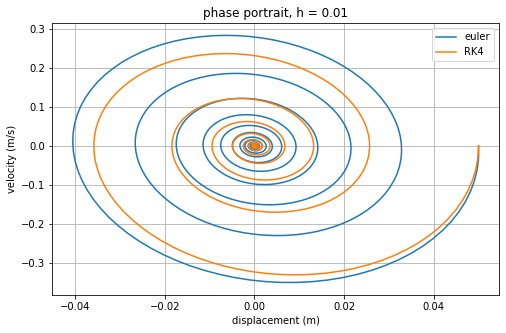

In [11]:
h = 0.01

t_euler, Y_euler = euler_method(h)
t_rk4, Y_rk4 = rk4_method(h)

plt.figure(figsize=(8,5))
plt.plot(Y_euler[:,0], Y_euler[:,1], label="euler")
plt.plot(Y_rk4[:,0], Y_rk4[:,1], label="RK4")
plt.xlabel("displacement (m)")
plt.ylabel("velocity (m/s)")
plt.title("phase portrait, h = 0.01")
plt.legend()
plt.grid(True)
plt.show()

Section 5

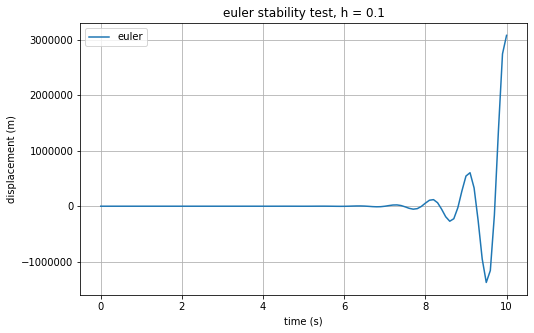

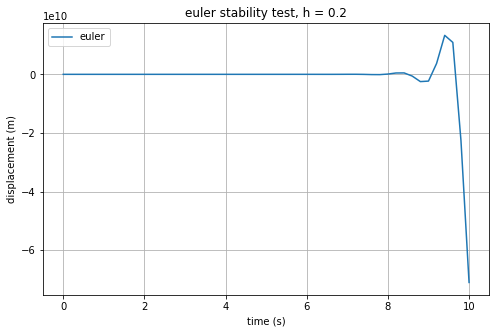

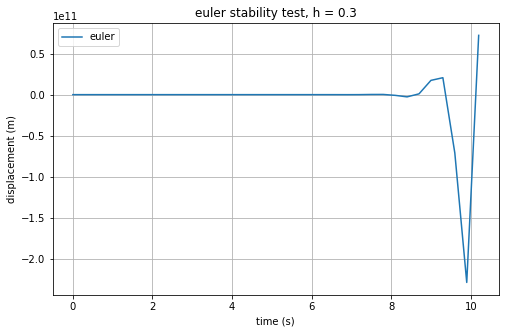

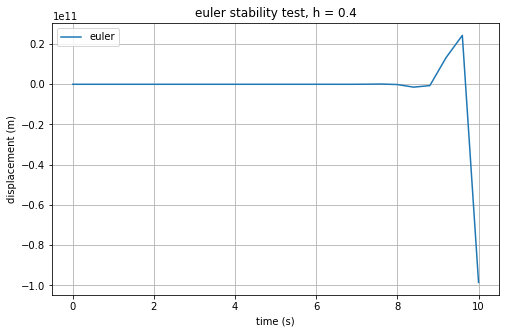

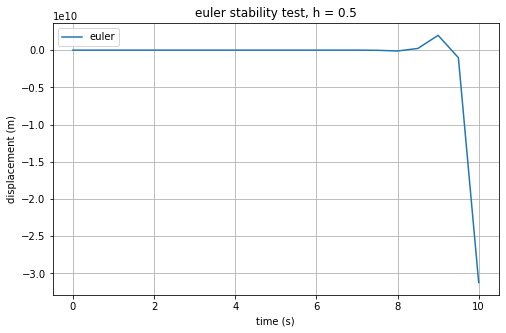

In [12]:
large_h_values = [0.1, 0.2, 0.3, 0.4, 0.5]

for h in large_h_values:
    t_euler, Y_euler = euler_method(h)
    
    plt.figure(figsize=(8,5))
    plt.plot(t_euler, Y_euler[:,0], label="euler")
    plt.xlabel("time (s)")
    plt.ylabel("displacement (m)")
    plt.title("euler stability test, h = " + str(h))
    plt.legend()
    plt.grid(True)
    plt.show()

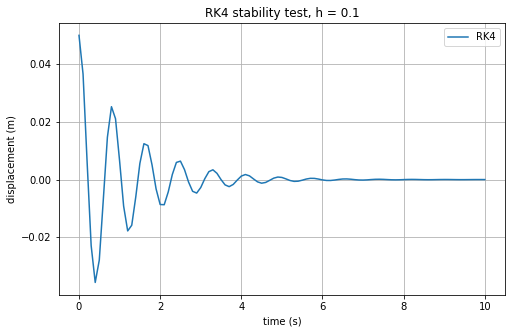

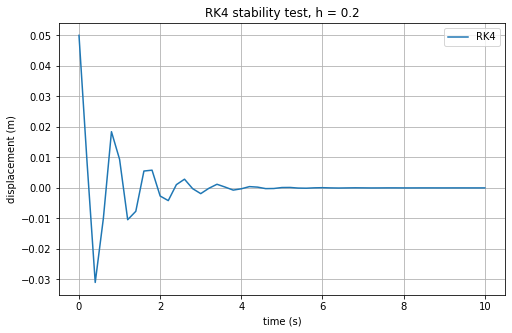

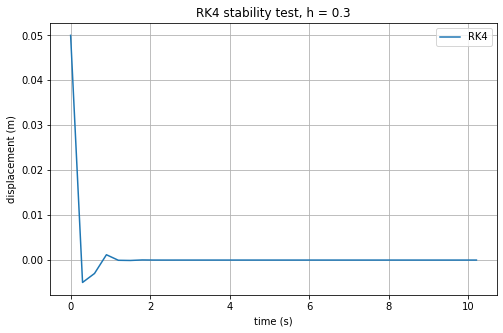

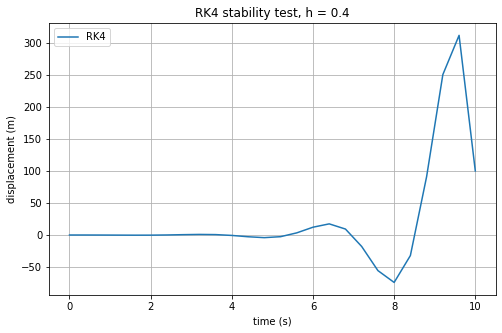

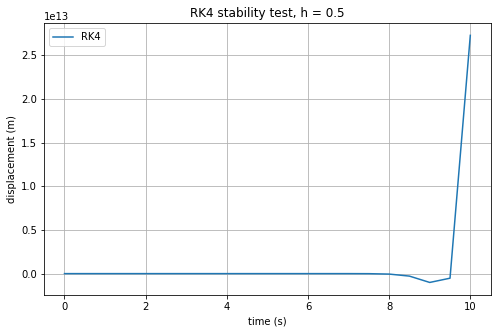

In [13]:
for h in large_h_values:
    t_rk4, Y_rk4 = rk4_method(h)
    
    plt.figure(figsize=(8,5))
    plt.plot(t_rk4, Y_rk4[:,0], label="RK4")
    plt.xlabel("time (s)")
    plt.ylabel("displacement (m)")
    plt.title("RK4 stability test, h = " + str(h))
    plt.legend()
    plt.grid(True)
    plt.show()

Error Analysis

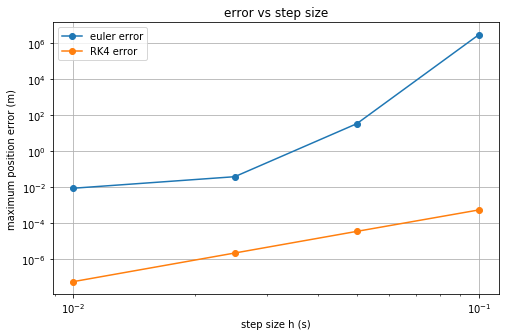

In [14]:
#use RK4 with very small step size
h_ref = 0.001
t_ref, Y_ref = rk4_method(h_ref)

def get_reference_values(t_values):
    ref_position = np.interp(t_values, t_ref, Y_ref[:,0])
    return ref_position

h_error_values = [0.1, 0.05, 0.025, 0.01]

euler_errors = []
rk4_errors = []

for h in h_error_values:
    t_euler, Y_euler = euler_method(h)
    t_rk4, Y_rk4 = rk4_method(h)
    
    ref_euler = get_reference_values(t_euler)
    ref_rk4 = get_reference_values(t_rk4)
    
    euler_error = np.max(np.abs(Y_euler[:,0] - ref_euler))
    rk4_error = np.max(np.abs(Y_rk4[:,0] - ref_rk4))
    
    euler_errors.append(euler_error)
    rk4_errors.append(rk4_error)

plt.figure(figsize=(8,5))
plt.loglog(h_error_values, euler_errors, marker="o", label="euler error")
plt.loglog(h_error_values, rk4_errors, marker="o", label="RK4 error")
plt.xlabel("step size h (s)")
plt.ylabel("maximum position error (m)")
plt.title("error vs step size")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
#estimate slopes of plots
euler_slope = np.polyfit(np.log(h_error_values), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(h_error_values), np.log(rk4_errors), 1)[0]

print("euler convergence slope=", euler_slope)
print("RK4 convergence slope=", rk4_slope)

euler convergence slope= 8.441653025616406
RK4 convergence slope= 3.9998034299565624


AI Assistance: Used ChatGPT for minor debugging and formatting help in Python.
Prompt was focused on fixing syntax and improving code readability, not generating full solutions.